# Mutual Fund Performance Analytics

This notebook evaluates the historical performance of the mutual fund using financial metrics such as Daily Return, CAGR, Annualized Return, Volatility, Sharpe Ratio, Sortino Ratio, Maximum Drawdown, and Rolling Performance Analysis.

These metrics help investors understand both return potential and associated investment risks.

## Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

## Load Dataset

In [6]:
df = pd.read_csv("../data/processed/cleaned_nav.csv")

df.head()

,date,nav
0,2013-11-18,13.0894
1,2013-11-19,13.1068
2,2013-11-20,12.9549
3,2013-11-21,12.7957
4,2013-11-22,12.7775


## Dataset Overview

In [4]:
print("Shape :", df.shape)

print("\nColumns")
print(df.columns)

print("\nInformation")
df.info()

print("\nMissing Values")
print(df.isnull().sum())

Shape : (3107, 2)

Columns
Index(['date', 'nav'], dtype='object')

Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3107 entries, 0 to 3106
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    3107 non-null   object 
 1   nav     3107 non-null   float64
dtypes: float64(1), object(1)
memory usage: 48.7+ KB

Missing Values
date    0
nav     0
dtype: int64


## Data Preprocessing

In [8]:
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date")

df.reset_index(drop=True, inplace=True)

df.head()

,date,nav
0,2013-11-18,13.0894
1,2013-11-19,13.1068
2,2013-11-20,12.9549
3,2013-11-21,12.7957
4,2013-11-22,12.7775


## Daily Return Analysis

Daily Return measures the percentage change in the Net Asset Value (NAV) from one trading day to the next.

It is the foundation for calculating other important performance metrics such as volatility, Sharpe Ratio, and Maximum Drawdown.

In [9]:
# Calculate Daily Return
df["daily_return"] = df["nav"].pct_change()

# Display first few rows
df.head()

,date,nav,daily_return
0,2013-11-18,13.0894,NaN
1,2013-11-19,13.1068,0.001329
2,2013-11-20,12.9549,-0.011589
3,2013-11-21,12.7957,-0.012289
4,2013-11-22,12.7775,-0.001422


In [7]:
# Summary Statistics
df["daily_return"].describe()

count    3106.000000
mean        0.000930
std         0.009576
min        -0.096964
25%        -0.003338
50%         0.001502
75%         0.006257
max         0.046026
Name: daily_return, dtype: float64

### Observation

The first value of Daily Return is NaN because there is no previous trading day available for comparison.

Positive values indicate an increase in NAV, whereas negative values indicate a decline.

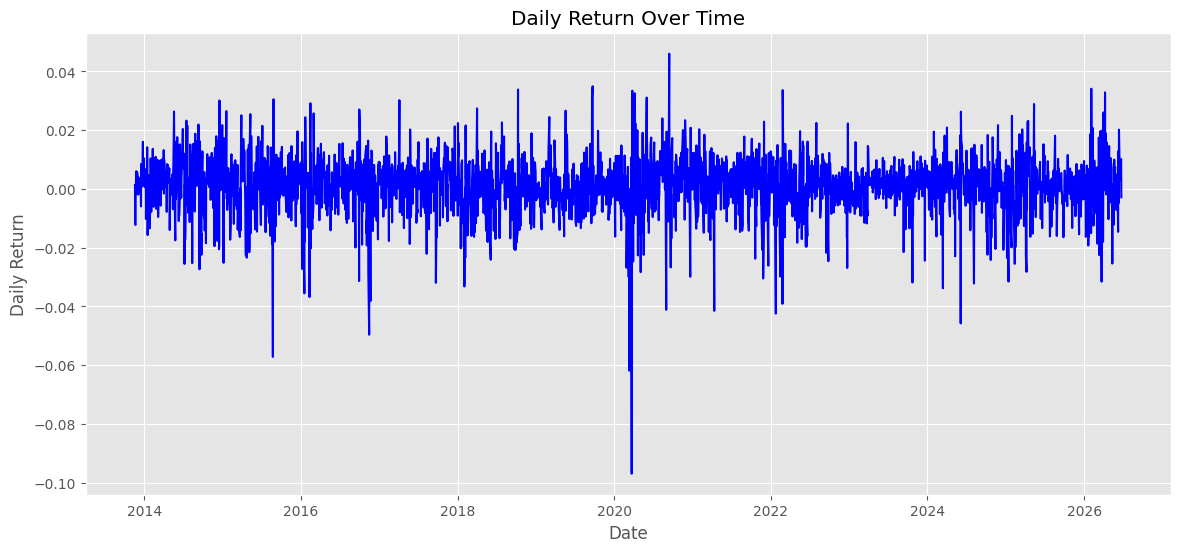

In [8]:
# Plot Daily Returns

plt.figure(figsize=(14,6))

plt.plot(df["date"], df["daily_return"], color="blue")

plt.title("Daily Return Over Time")

plt.xlabel("Date")

plt.ylabel("Daily Return")

plt.grid(True)

plt.show()

### Business Insight

The Daily Return chart shows how the mutual fund performed on each trading day.

Frequent sharp fluctuations indicate higher volatility, while smoother movements indicate relatively stable performance.

## Annualized Return

In [9]:
trading_days = 252

annualized_return = ((1 + df["daily_return"].mean()) ** trading_days) - 1

print(f"Annualized Return: {annualized_return:.2%}")

Annualized Return: 26.40%


### Observation

Annualized Return estimates the yearly return of the mutual fund based on its average daily return.

Higher annualized returns generally indicate better long-term performance.

## Volatility

In [10]:
volatility = df["daily_return"].std() * np.sqrt(252)

print(f"Annualized Volatility: {volatility:.2%}")

Annualized Volatility: 15.20%


### Observation

Annualized Volatility measures the level of risk associated with the mutual fund.

Higher volatility indicates larger fluctuations in returns and therefore higher investment risk.

## Volatility Visualization

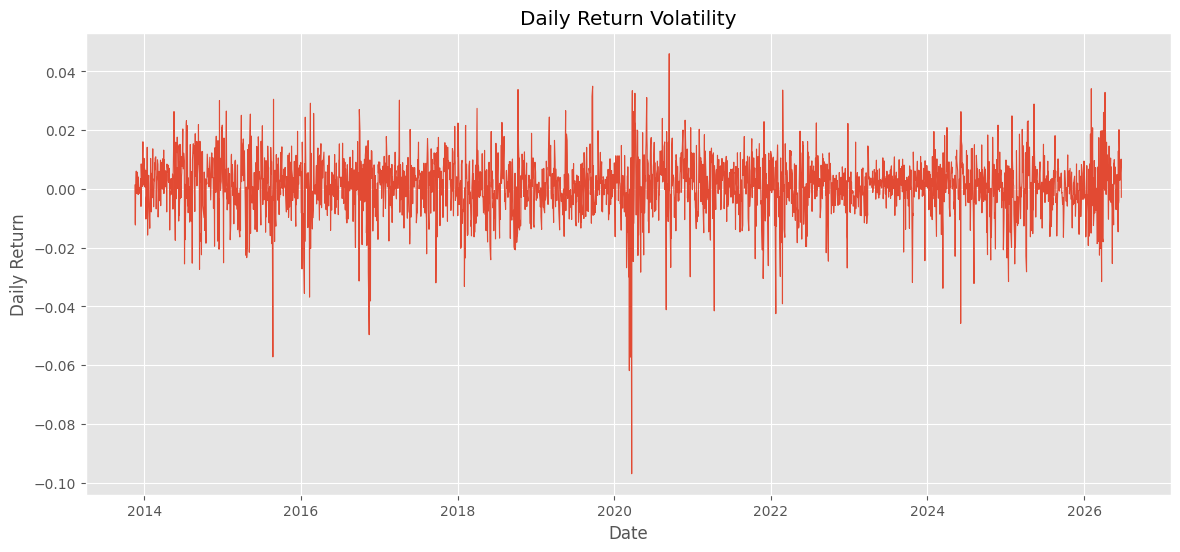

In [11]:
plt.figure(figsize=(14,6))

plt.plot(df["date"], df["daily_return"], linewidth=0.8)

plt.title("Daily Return Volatility")

plt.xlabel("Date")

plt.ylabel("Daily Return")

plt.grid(True)

plt.show()

## Compound Annual Growth Rate (CAGR)

In [12]:
initial_nav = df["nav"].iloc[0]

final_nav = df["nav"].iloc[-1]

years = (df["date"].iloc[-1] - df["date"].iloc[0]).days / 365.25

cagr = ((final_nav / initial_nav) ** (1 / years)) - 1

print(f"CAGR: {cagr:.2%}")

CAGR: 24.34%


### Observation

CAGR represents the average annual growth rate of the mutual fund over the entire investment period.

Unlike simple returns, CAGR considers the compounding effect and provides a better measure of long-term performance.

## Cumulative NAV Growth

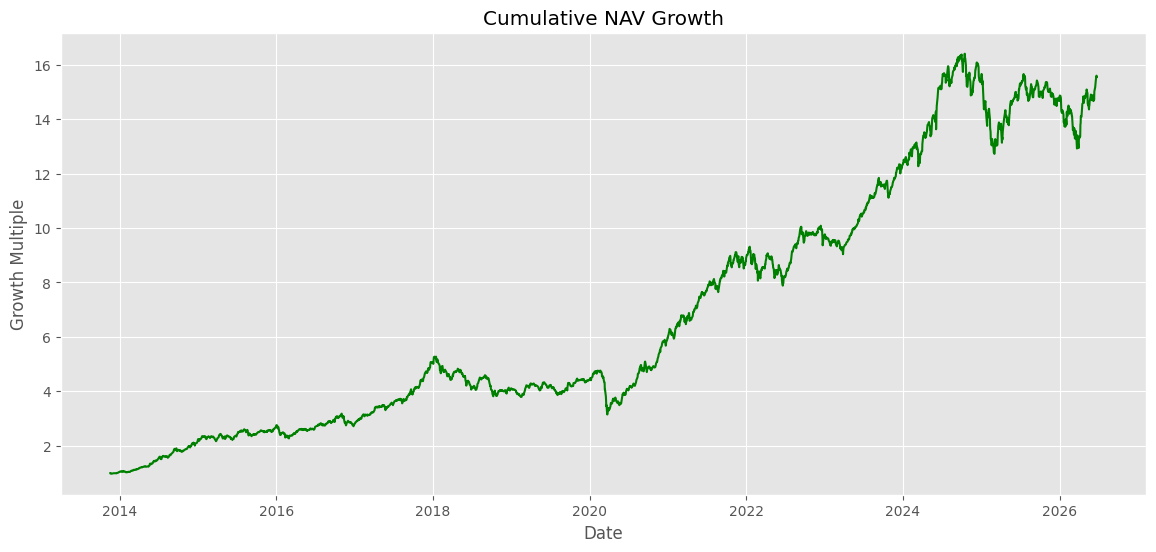

In [13]:
df["cumulative_growth"] = df["nav"] / initial_nav

plt.figure(figsize=(14,6))

plt.plot(df["date"], df["cumulative_growth"], color="green")

plt.title("Cumulative NAV Growth")

plt.xlabel("Date")

plt.ylabel("Growth Multiple")

plt.grid(True)

plt.show()

### Business Insight

The cumulative growth chart shows how many times the investment has grown since the beginning of the observation period.

An upward trend indicates long-term wealth creation and consistent fund performance.

## Sharpe Ratio

In [14]:
risk_free_rate = 0.07

sharpe_ratio = (annualized_return - risk_free_rate) / volatility

print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

Sharpe Ratio: 1.28


### Observation

The Sharpe Ratio evaluates the return generated for each unit of investment risk.

A higher Sharpe Ratio indicates better risk-adjusted performance.

## Sharpe Ratio Interpretation

In [15]:
if sharpe_ratio > 2:
    print("Excellent Risk-Adjusted Performance")

elif sharpe_ratio > 1:
    print("Good Risk-Adjusted Performance")

elif sharpe_ratio > 0:
    print("Acceptable Risk-Adjusted Performance")

else:
    print("Poor Risk-Adjusted Performance")

Good Risk-Adjusted Performance


### Business Insight

The Sharpe Ratio helps investors compare different mutual funds by evaluating returns relative to the level of risk taken.

Funds with consistently higher Sharpe Ratios are generally considered more efficient investments.

## Sortino Ratio

In [16]:
downside_returns = df[df["daily_return"] < 0]["daily_return"]

downside_deviation = downside_returns.std() * np.sqrt(252)

sortino_ratio = (annualized_return - risk_free_rate) / downside_deviation

print(f"Sortino Ratio: {sortino_ratio:.2f}")

Sortino Ratio: 1.54


### Observation

The Sortino Ratio evaluates investment performance by considering only downside volatility.

Unlike the Sharpe Ratio, it ignores positive fluctuations and focuses only on harmful risk.

## Sortino Ratio Interpretation

In [17]:
if sortino_ratio > 2:
    print("Excellent Downside Risk-Adjusted Performance")

elif sortino_ratio > 1:
    print("Good Downside Risk-Adjusted Performance")

elif sortino_ratio > 0:
    print("Acceptable Downside Risk-Adjusted Performance")

else:
    print("Poor Downside Risk-Adjusted Performance")

Good Downside Risk-Adjusted Performance


### Business Insight

The Sortino Ratio is particularly useful for conservative investors because it evaluates returns by considering only downside risk.

A higher Sortino Ratio indicates that the fund generates better returns while minimizing losses.

## Maximum Drawdown (MDD)

In [18]:
df["rolling_max"] = df["nav"].cummax()

df["drawdown"] = (df["nav"] - df["rolling_max"]) / df["rolling_max"]

max_drawdown = df["drawdown"].min()

print(f"Maximum Drawdown: {max_drawdown:.2%}")

Maximum Drawdown: -40.26%


### Observation

Maximum Drawdown represents the largest decline from a historical peak in the mutual fund's NAV.

Lower drawdown indicates better capital preservation and lower investment risk.

## Maximum Drawdown Visualization

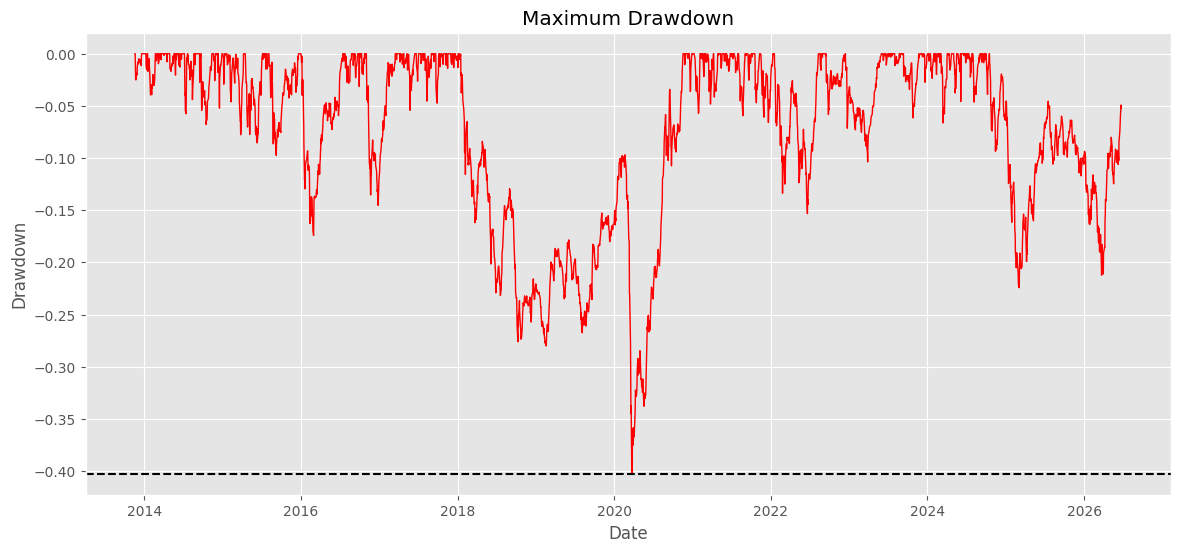

In [19]:
plt.figure(figsize=(14,6))

plt.plot(df["date"], df["drawdown"], color="red", linewidth=1)

plt.axhline(y=max_drawdown, color="black", linestyle="--")

plt.title("Maximum Drawdown")

plt.xlabel("Date")

plt.ylabel("Drawdown")

plt.grid(True)

plt.show()

### Business Insight

The Maximum Drawdown chart highlights the worst historical loss experienced by the mutual fund.

Funds with smaller drawdowns are generally considered more resilient during market downturns and are preferred by risk-averse investors.

## Rolling Return (90-Day)

In [20]:
df["rolling_return"] = df["daily_return"].rolling(window=90).mean() * 252

df[["date", "rolling_return"]].tail()

,date,rolling_return
3102,2026-06-17,0.221637
3103,2026-06-18,0.253521
3104,2026-06-19,0.210854
3105,2026-06-22,0.231091
3106,2026-06-23,0.212333


### Observation

The Rolling Return represents the average annualized return over the previous 90 trading days.

It helps identify periods of strong and weak fund performance.

## Rolling Return Visualization

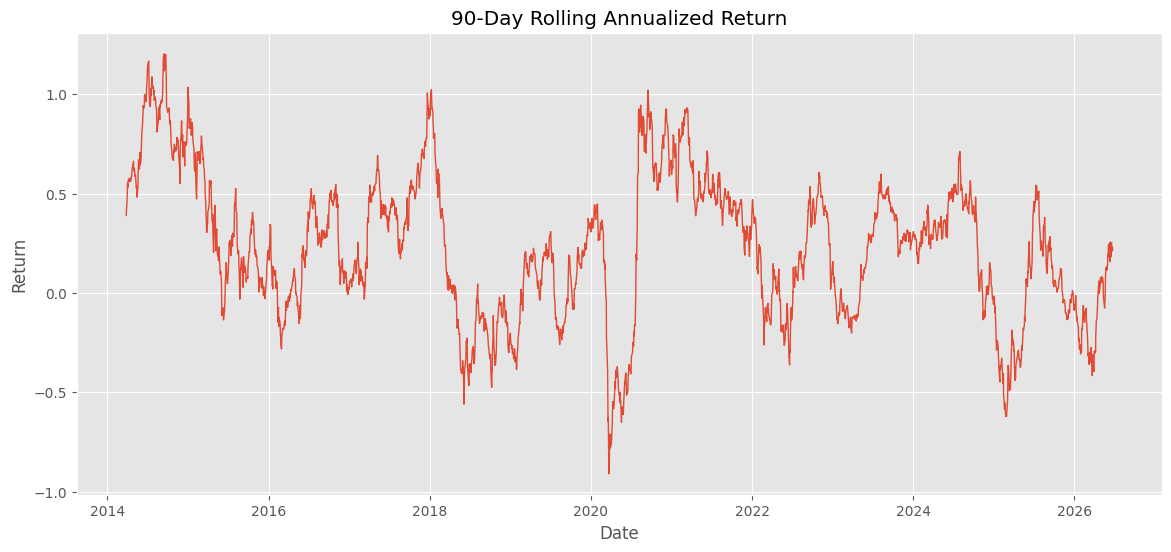

In [21]:
plt.figure(figsize=(14,6))

plt.plot(df["date"], df["rolling_return"], linewidth=1)

plt.title("90-Day Rolling Annualized Return")

plt.xlabel("Date")

plt.ylabel("Return")

plt.grid(True)

plt.show()

## Rolling Volatility

In [22]:
df["rolling_volatility"] = df["daily_return"].rolling(window=90).std() * np.sqrt(252)

df[["date", "rolling_volatility"]].tail()

,date,rolling_volatility
3102,2026-06-17,0.180635
3103,2026-06-18,0.180456
3104,2026-06-19,0.177498
3105,2026-06-22,0.178149
3106,2026-06-23,0.178190


### Observation

Rolling Volatility measures how investment risk changes over time.

Higher values indicate periods of increased market uncertainty.

## Rolling Volatility Visualization

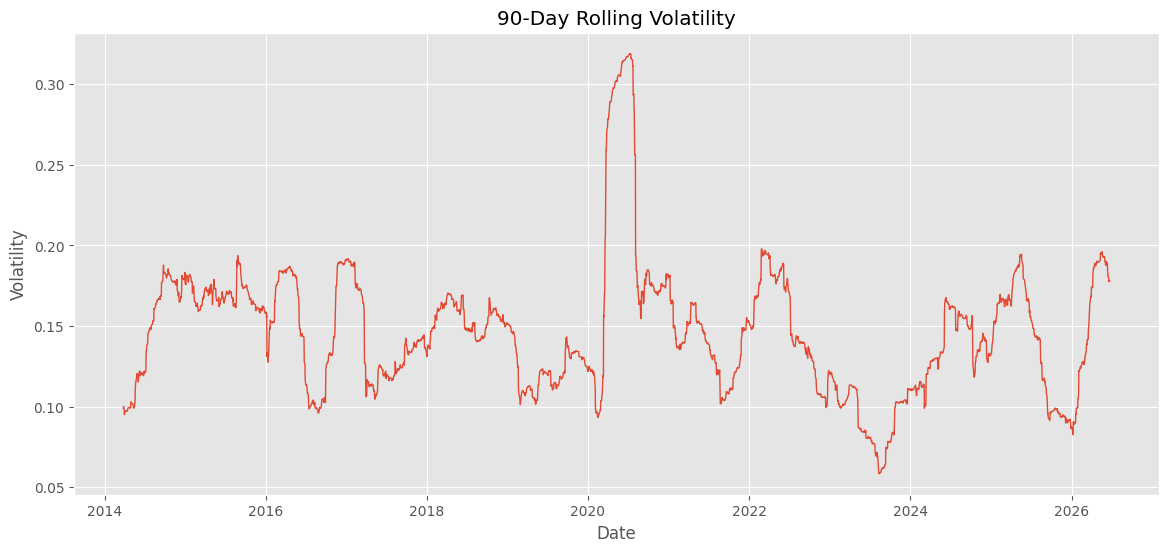

In [23]:
plt.figure(figsize=(14,6))

plt.plot(df["date"], df["rolling_volatility"], linewidth=1)

plt.title("90-Day Rolling Volatility")

plt.xlabel("Date")

plt.ylabel("Volatility")

plt.grid(True)

plt.show()

## Rolling Sharpe Ratio

In [24]:
rolling_mean = df["daily_return"].rolling(window=90).mean() * 252

rolling_std = df["daily_return"].rolling(window=90).std() * np.sqrt(252)

df["rolling_sharpe"] = (rolling_mean - risk_free_rate) / rolling_std

df[["date", "rolling_sharpe"]].tail()

,date,rolling_sharpe
3102,2026-06-17,0.839469
3103,2026-06-18,1.016985
3104,2026-06-19,0.793552
3105,2026-06-22,0.904248
3106,2026-06-23,0.798770


### Observation

The Rolling Sharpe Ratio tracks the fund's risk-adjusted performance over successive 90-day periods.

Higher values indicate more efficient returns relative to the risk taken during that period.

## Rolling Sharpe Ratio Visualization

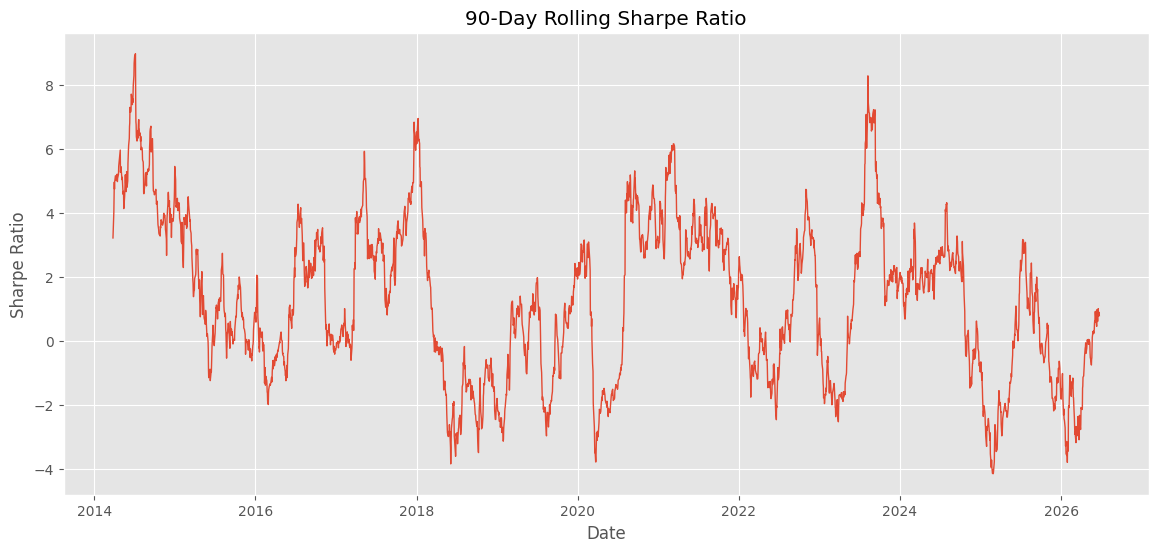

In [25]:
plt.figure(figsize=(14,6))

plt.plot(df["date"], df["rolling_sharpe"], linewidth=1)

plt.title("90-Day Rolling Sharpe Ratio")

plt.xlabel("Date")

plt.ylabel("Sharpe Ratio")

plt.grid(True)

plt.savefig("../reports/rolling_sharpe_chart.png", dpi=300, bbox_inches="tight")

plt.show()

### Business Insight

The 90-Day Rolling Sharpe Ratio highlights how efficiently the mutual fund generated returns relative to risk across different market periods.

Periods with higher Sharpe Ratios indicate stronger risk-adjusted performance, while lower values suggest that investors assumed more risk for comparatively lower returns.

# Performance Metrics Summary

In [26]:
summary = pd.DataFrame({
    "Metric": [
        "Annualized Return",
        "CAGR",
        "Volatility",
        "Sharpe Ratio",
        "Sortino Ratio",
        "Maximum Drawdown"
    ],
    "Value": [
        f"{annualized_return:.2%}",
        f"{cagr:.2%}",
        f"{volatility:.2%}",
        f"{sharpe_ratio:.2f}",
        f"{sortino_ratio:.2f}",
        f"{max_drawdown:.2%}"
    ]
})

summary

,Metric,Value
0,Annualized Return,26.40%
1,CAGR,24.34%
2,Volatility,15.20%
3,Sharpe Ratio,1.28
4,Sortino Ratio,1.54
5,Maximum Drawdown,-40.26%


In [27]:
summary.to_csv("../data/processed/performance_summary.csv", index=False)

print("performance_summary.csv saved successfully.")

performance_summary.csv saved successfully.


In [28]:
rolling_metrics = df[
    [
        "date",
        "rolling_return",
        "rolling_volatility",
        "rolling_sharpe"
    ]
]

rolling_metrics.to_csv(
    "../data/processed/rolling_metrics.csv",
    index=False
)

print("rolling_metrics.csv saved successfully.")

rolling_metrics.csv saved successfully.


In [29]:
drawdown_data = df[
    [
        "date",
        "drawdown"
    ]
]

drawdown_data.to_csv(
    "../data/processed/drawdown_data.csv",
    index=False
)

print("drawdown_data.csv saved successfully.")

drawdown_data.csv saved successfully.


In [30]:
df["rolling_return"]

df["rolling_volatility"]

df["rolling_sharpe"]

df["drawdown"]

0       0.000000
1       0.000000
2      -0.011589
3      -0.023736
4      -0.025124
          ...   
3102   -0.069157
3103   -0.063911
3104   -0.058696
3105   -0.049146
3106   -0.051857
Name: drawdown, Length: 3107, dtype: float64

In [31]:
df.columns

Index(['date', 'nav', 'daily_return', 'cumulative_growth', 'rolling_max',
       'drawdown', 'rolling_return', 'rolling_volatility', 'rolling_sharpe'],
      dtype='object')

In [10]:
df.columns

Index(['date', 'nav', 'daily_return'], dtype='object')